### Perform Clustering

In [10]:
# Imports
import numpy as np
import os, sys
import matplotlib.pyplot as plt

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from clustering import Cluster
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset, save_cluster, parameter_plot
from sensor_processing import sensor_processing

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [11]:
bounds = config_global["data"]["param_bounds"]
param_bounds = []
for key in bounds.keys():
    param_bounds.append([min(bounds[key]), max(bounds[key])])

In [12]:
# Minimum number of data points in each cluster
n_train_per_cluster = 16
n_val_per_cluster = 16
n_test_per_cluster = 128
normalize = False

In [13]:
dataset_path = os.path.join(output_dir, "datasets")
FS_train, param_train, ft_train, disp_norm, vel_norm, ft_norm = load_dataset(os.path.join(dataset_path, "Train"), normalize=normalize)
FS_val, param_val, ft_val, _, _, _ = load_dataset(os.path.join(dataset_path, "Val"), normalize, disp_norm, vel_norm, ft_norm)
FS_test, param_test, ft_test, _, _, _ = load_dataset(os.path.join(dataset_path, "Test"), normalize, disp_norm, vel_norm, ft_norm)

In [14]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

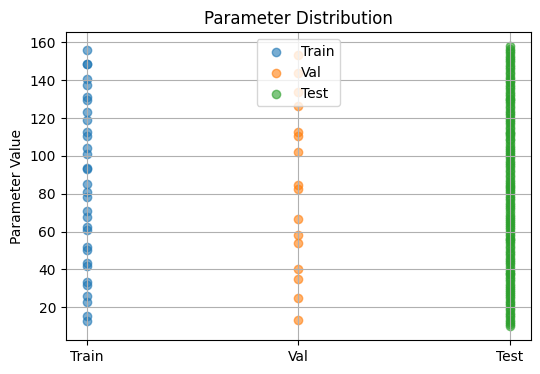

In [15]:
parameter_plot(param_train, param_val, param_test)

Perform Clustering

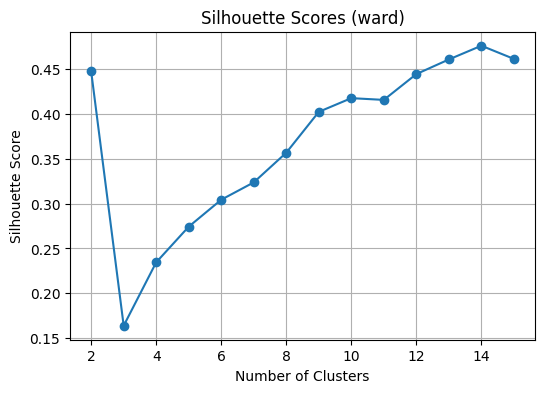

k=2, silhouette=0.448
k=3, silhouette=0.164
k=4, silhouette=0.235
k=5, silhouette=0.274
k=6, silhouette=0.304
k=7, silhouette=0.324
k=8, silhouette=0.357
k=9, silhouette=0.402
k=10, silhouette=0.418
k=11, silhouette=0.416
k=12, silhouette=0.445
k=13, silhouette=0.461
k=14, silhouette=0.476
k=15, silhouette=0.462


In [16]:
clust = Cluster(RS_train[:, 1], param_train, bounds = param_bounds, seed=config_global["seed"]) # clustering using velocity data
sil_scores = clust.find_best_k_by_silhouette(k_range=range(2, 16), method="ward")

Choose optimal number of clusters

In [17]:
n_clusters = 5

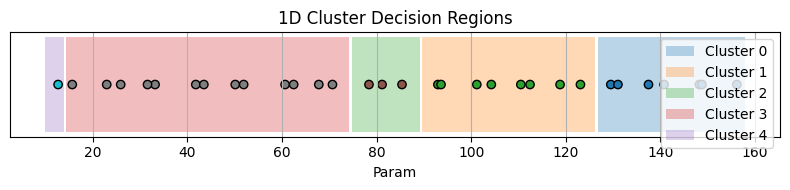

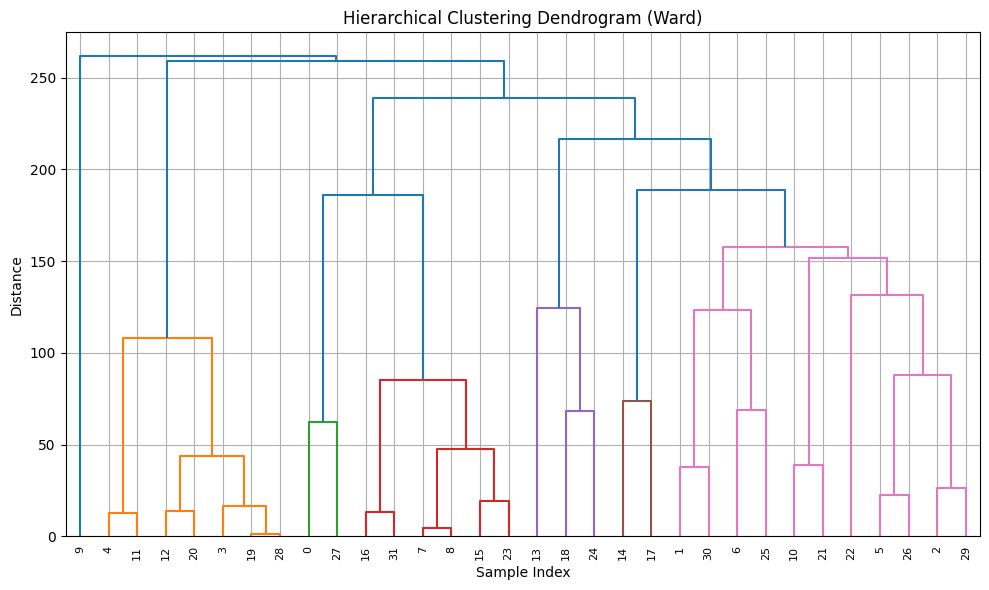

In [18]:
clust.find_clusters(n_clusters=n_clusters, method="ward")
clust.plot_decision_regions()
clust.plot_dendrogram()

##### Generate Greater Cluster Data

In [ ]:
generated = clust.balance_cluster_points(min_points=n_train_per_cluster)

In [10]:
generated.keys()

dict_keys([0, 1, 2, 3, 4])

In [11]:
all_new_params = np.vstack(list(generated.values()))
combined_params = np.vstack([clust.params, all_new_params])

In [11]:
generated[4]

array([[12.63656496],
       [12.94834058],
       [11.73992116],
       [ 9.99215324],
       [12.61099575],
       [13.90289955],
       [13.08087116],
       [13.69165863],
       [11.73785289],
       [12.13929815],
       [ 9.97490099],
       [11.72536293],
       [12.87537942],
       [11.71531315],
       [13.374408  ]])

In [14]:
print(combined_params)

[[118.80112885]
 [ 33.1504289 ]
 [ 70.66286258]
 [156.18720067]
 [129.5322214 ]
 [ 62.45959921]
 [ 25.87771302]
 [ 92.96854763]
 [ 93.62842755]
 [ 12.63933108]
 [ 50.10658475]
 [131.0416076 ]
 [140.79933626]
 [ 78.38775281]
 [ 41.76068661]
 [104.26277072]
 [110.50378099]
 [ 43.46730734]
 [ 81.16046742]
 [148.28744173]
 [137.50428099]
 [ 51.88972957]
 [ 15.63314351]
 [101.19362131]
 [ 85.37200648]
 [ 22.92428332]
 [ 60.64455163]
 [123.11048721]
 [148.80272201]
 [ 67.77748583]
 [ 31.548008  ]
 [112.44688232]
 [145.79752729]
 [141.22280796]
 [155.24091743]
 [138.187415  ]
 [135.19447536]
 [152.28453804]
 [151.10223201]
 [156.06349128]
 [138.64718432]
 [118.44975165]
 [116.58840461]
 [102.95506389]
 [104.69044477]
 [124.15961461]
 [102.64075198]
 [ 90.39066935]
 [ 97.85364296]
 [ 86.89204403]
 [ 82.12874796]
 [ 85.74340506]
 [ 88.66116429]
 [ 75.01438317]
 [ 82.51217504]
 [ 77.10431846]
 [ 81.5335601 ]
 [ 77.24396987]
 [ 85.14578016]
 [ 84.91792723]
 [ 84.30471463]
 [ 82.88394325]
 [ 66.77

In [11]:
for cluster in range(n_clusters):
    save_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, FS_train, param_train, ft_train, disp_norm, vel_norm, ft_norm)
    save_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, FS_val, param_val, ft_val, disp_norm, vel_norm, ft_norm)
    save_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, FS_test, param_test, ft_test, disp_norm, vel_norm, ft_norm)

In [12]:
config_global["data"]["n_clusters"] = n_clusters
save_config(config_file, config_global)